In [22]:
import mne
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from mne import combine_evoked
from mne.minimum_norm import apply_inverse
import random
from mne.datasets import sample
import math
from mne.datasets import fetch_fsaverage
import os.path as op
import seaborn as sns
import pandas as pd
import statsmodels.stats.api as sms

In [48]:
fs_dir = fetch_fsaverage(verbose=True)
subjects_dir = op.dirname(fs_dir)
subject = 'fsaverage'
trans = 'fsaverage'  # MNE has a built-in fsaverage transformation
snr = 3.0
lambda2 = 1.0 / snr ** 2
src = mne.setup_source_space(subject, spacing='ico4', add_dist='patch',subjects_dir=subjects_dir)
conductivity = (0.3, 0.006, 0.3)  # for three layers
model = mne.make_bem_model(subject=subject, ico=3,conductivity=conductivity,subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)

stc_EFE1 = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_beta')
stc_EFE1_p = mne.read_source_estimate('./stc_result/reg_SCE_EFE1_mlog10_p_val')
stc_EX1 = mne.read_source_estimate('./stc_result/reg_SCE_EX1_beta')
stc_EX1_p = mne.read_source_estimate('./stc_result/reg_SCE_EX1_mlog10_p_val')
stc_AI1 = mne.read_source_estimate('./stc_result/reg_SCE_AI1_beta')
stc_AI1_p = mne.read_source_estimate('./stc_result/reg_SCE_AI1_mlog10_p_val')
stc_AL1 = mne.read_source_estimate('./stc_result/reg_SCE_AL1_beta')
stc_AL1_p = mne.read_source_estimate('./stc_result/reg_SCE_AL1_mlog10_p_val')
stc_EFE2 = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_beta')
stc_EFE2_p = mne.read_source_estimate('./stc_result/reg_SRE_EFE2_mlog10_p_val')
stc_AL2 = mne.read_source_estimate('./stc_result/reg_SRE_AL2_beta')
stc_AL2_p = mne.read_source_estimate('./stc_result/reg_SRE_AL2_mlog10_p_val')
stc_EX2 = mne.read_source_estimate('./stc_result/reg_SRE_EX2_beta')
stc_EX2_p = mne.read_source_estimate('./stc_result/reg_SRE_EX2_mlog10_p_val')
stc_REX2 = mne.read_source_estimate('./stc_result/reg_SRR_REX2_beta')
stc_REX2_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_mlog10_p_val')
stc_PEEX2 = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_beta')
stc_PEEX2_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_mlog10_p_val')
stc_RAL2 = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_beta')
stc_RAL2_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_mlog10_p_val')
stc_RAI1 = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_beta')
stc_RAI1_p = mne.read_source_estimate('./stc_result/reg_SCR_RAI1_mlog10_p_val')

stc_UAL = mne.read_source_estimate('./stc_result/reg_SRE_UAL_beta')
stc_UAL_p = mne.read_source_estimate('./stc_result/reg_SRE_UAL_mlog10_p_val')


stc_REX2_risk = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_beta')
stc_REX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_REX2_risk_mlog10_p_val')
stc_PEEX2_risk = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_beta')
stc_PEEX2_risk_p = mne.read_source_estimate('./stc_result/reg_SRPE_PEEX2_risk_mlog10_p_val')
stc_RAL2_risk = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_beta')
stc_RAL2_risk_p = mne.read_source_estimate('./stc_result/reg_SRR_RAL2_risk_mlog10_p_val')

0 files missing from root.txt in C:\Users\47648\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\47648\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/163842 selected to source space (ico = 4)

Loading C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\4

c:\Users\47648\anaconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  If True (default), then PEP440 development markers like ``.devN``
c:\Users\47648\anaconda3\envs\MNE\Lib\site-packages\mne\utils\check.py:92: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  If True (default), then PEP440 development markers like ``.devN``


    Computing patch statistics...
    Patch information added...
    Computing patch statistics...
    Patch information added...
You are now one step closer to computing the gain matrix
Creating the BEM geometry...
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
Going from 5th to 3th subdivision of an icosahedron (n_tri: 20480 -> 1280)
outer skin  CM is  -0.21 -19.38  -0.22 mm
outer skull CM is  -0.19 -19.35  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is app

In [4]:
DATA = stc_UAL.data
DATA_p = stc_UAL_p.data
if np.mean(DATA)<0:
    stc_UAL.data = np.where(DATA <= 0, -DATA, 0)
    DATA = stc_UAL.data
print(np.mean(DATA))

4.976317e-12


In [3]:
vertno_max, time_max = stc_REX2.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_REX2.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

Using pyvistaqt 3d backend.



c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)


In [5]:
vertno_max, time_max = stc_UAL.get_peak()
surfer_kwargs = dict(hemi='both',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_UAL.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

Using pyvistaqt 3d backend.



c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\backends\_pyvista.py:41: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  VTK9 = LooseVersion(getattr(vtk, 'VTK_VERSION', '9.0')) >= LooseVersion('9.0')
c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


In [ ]:
vertno_max, time_max = stc_EFE1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EFE1_p.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

In [24]:
vertno_max, time_max = stc_EX1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_EX1_p.plot(**surfer_kwargs)
# brain_.add_foci([-8.02950478, 64.38530731, -2.29914141],color = [1,1,0],hemi='lh')

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
Reading labels from parcellation...
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot


c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)
Extracting time courses for 1 labels (mode: mean)


In [23]:
vertno_max, time_max = stc_AI1.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[300, 308, 310]),surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_AI1.plot(**surfer_kwargs)
brain_.add_foci([9.86565685,  0.72324908, 39.92936325],color = [1,1,0],hemi='rh')

c:\Users\dell\miniconda3\envs\MNE\Lib\site-packages\mne\viz\_brain\_brain.py:1728: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  self.time_line.set_xdata(current_time)


In [ ]:
# vertno_max, time_max = stc_AI1_p.get_peak()
surfer_kwargs = dict(hemi='split',subject=subject, subjects_dir=subjects_dir,clim=dict(kind='value', lims=[1.31,2,3]), surface='white', 
                     views='lateral',initial_time=time_max, time_unit='s', size=(800, 800), smoothing_steps=10,background='white')
brain_ = stc_UAL_p.plot(**surfer_kwargs)

In [25]:
label_data_p = stc_UAL_p.in_label(label).data
print(np.shape(label_data_p)[1])

501


In [54]:
def FDR(p_values):
    corrected_p_values = np.zeros_like(p_values)
    for i in range(np.shape(label_data_p)[1]):
        p_values_time_point = p_values[:, i]
        # 执行 FDR 矫正
        rejected, p_corrected, _, _ = sms.multipletests(p_values_time_point, method='fdr_bh')
        # 存储矫正后的 p 值
        corrected_p_values[:, i] = p_corrected
    return  corrected_p_values

def p2mlogp(p_values):
    # 为了避免对数为负无穷，设置一个很小的正数
    epsilon = 1e-10
    p_values_safe = np.maximum(p_values, epsilon)
    # 计算 log10(p_values)
    log10_p_values = -np.log10(p_values_safe)
    return log10_p_values

def mlogp2p(p_values):
    p_values_recovered = 10 ** (p_values)
    return p_values_recovered

def mlogp_FDR(p_values):
    p_values_normal = mlogp2p(p_values)
    p_values_normal_corrected = FDR(p_values_normal)
    p_value_corrected = p2mlogp(p_values_normal_corrected)
    return p_value_corrected

In [57]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
labels_beta = []
labels_time = []
labels_fraction = []
fraction = 0.5
p_value = 1.30103
# p_value = 2
# p_value = 3
# p_value = 8
for label in labels:    
    label_effective_time = 0
    label_effective_beta = 0
    label_effective_fraction = 0
    
    label_data = stc_EFE2.in_label(label).data
    corrected_data_p = mlogp_FDR(stc_UAL_p.data)
    stc_UAL_p.data = corrected_data_p
    label_data_p = stc_EFE2_p.in_label(label).data

    for j in range(501):
        time_effective_point = 0
        time_effective_beta = 0
        for i in range(len(label_data[:,0])):
            if label_data_p[i,j]>p_value:
                # point_effective_beta += label_data[i,j]
                time_effective_point += 1
        if time_effective_point >= len(label_data[:,0])*fraction:
            for i in range(len(label_data[:,0])):
                time_effective_beta += label_data[i,j]
            label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
            label_effective_time += 1
            label_effective_fraction += time_effective_point/len(label_data[:,0])
            
    if label_effective_time != 0:
        labels_beta.append([label.name,label_effective_beta/label_effective_time])
        labels_fraction.append([label.name,label_effective_fraction/label_effective_time])
    else :
        labels_beta.append(0)
        labels_fraction.append(0)
    labels_time.append([label.name,label_effective_time])
if p_value == 1.30103:
    print("p < 0.05")
elif p_value == 2:
    print("p < 0.01")
elif p_value == 3:
    print("p < 0.001")
for i in range(len(labels_time)):
    if labels_time[i][1]>250:
        print(labels_time[i][0],'time',labels_time[i][1]/250,'fraction','%.4f' % labels_fraction[i][1], 'beta','%.3E' % labels_beta[i][1])

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
p < 0.05
bankssts_1-lh time 2.0 fraction 1.0000 beta 2.171E-11
bankssts_1-rh time 2.0 fraction 0.9875 beta 1.825E-11
bankssts_2-lh time 2.0 fraction 0.9962 beta 2.273E-11
bankssts_2-rh time 1.992 fraction 0.9847 beta 1.679E-11
bankssts_3-lh time 2.0 fraction 0.9810 beta 2.125E-11
bankssts_3-rh time 2.0 fraction 0.9983 beta 1.680E-11
caudalanteriorcingulate_1-lh time 2.0 fraction 1.0000 beta 1.782E-11
caudalanteriorcingulate_1-rh time 2.0 fraction 1.0000 beta 1.927E-11
caudalanteriorcingulate_2-lh time 2.0 fraction 0.9939 beta 1.654E-11
caudalanteriorcingulate_2-rh time 2.0 fraction 0.9972 beta 1.773E-11
caudalanteriorcingulate_3-rh time 1.996 fraction 0.9918 beta 1.475E-11
caudalmiddlefrontal_1-lh time 2.0 fraction 1.0000 beta 1.746E-11
caudalmiddlef

In [17]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
labels_beta = []
labels_time = []
labels_fraction = []
fraction = 0.5
p_value = 1.30103
# p_value = 2
# p_value = 3
# p_value = 8
for label in labels:    
    label_effective_time = 0
    label_effective_beta = 0
    label_effective_fraction = 0
    
    label_data = stc_UAL.in_label(label).data
    label_data_p = stc_UAL_p.in_label(label).data

    for j in range(501):
        time_effective_point = 0
        time_effective_beta = 0
        for i in range(len(label_data[:,0])):
            if label_data_p[i,j]>p_value:
                # point_effective_beta += label_data[i,j]
                time_effective_point += 1
        if time_effective_point >= len(label_data[:,0])*fraction:
            for i in range(len(label_data[:,0])):
                time_effective_beta += label_data[i,j]
            label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
            label_effective_time += 1
            label_effective_fraction += time_effective_point/len(label_data[:,0])
            
    if label_effective_time != 0:
        labels_beta.append([label.name,label_effective_beta/label_effective_time])
        labels_fraction.append([label.name,label_effective_fraction/label_effective_time])
    else :
        labels_beta.append(0)
        labels_fraction.append(0)
    labels_time.append([label.name,label_effective_time])
if p_value == 1.30103:
    print("p < 0.05")
elif p_value == 2:
    print("p < 0.01")
elif p_value == 3:
    print("p < 0.001")
for i in range(len(labels_time)):
    if labels_time[i][1]>150:
        print(labels_time[i][0],'time',labels_time[i][1]/250,'fraction','%.4f' % labels_fraction[i][1], 'beta','%.3E' % labels_beta[i][1])

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
p < 0.05
frontalpole_1-lh time 0.648 fraction 0.7963 beta 2.166E-11
rostralmiddlefrontal_11-lh time 0.604 fraction 0.6556 beta 2.351E-11
superiorfrontal_1-lh time 0.632 fraction 0.7983 beta 2.350E-11


In [4]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
print(len(labels))

Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
450


In [19]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
effective_time_point = []
for label in labels:
    if label.name == "frontalpole_1-lh":
        label_data = stc_UAL.in_label(label).data
        label_data_p = stc_UAL_p.in_label(label).data
        for j in range(501):
            time_effective_point = 0
            time_effective_beta = 0
            for i in range(len(label_data[:,0])):
                if label_data_p[i,j]>p_value:
                    # point_effective_beta += label_data[i,j]
                    time_effective_point += 1
            if time_effective_point >= len(label_data[:,0])*fraction:
                for i in range(len(label_data[:,0])):
                    time_effective_beta += label_data[i,j]
                label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
                label_effective_time += 1
                effective_time_point.append(j)
print(effective_time_point)
print(np.max(label_data))

Reading labels from parcellation...
   read 226 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\47648\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
[148, 149, 150, 156, 157, 158, 159, 160, 161, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 200, 201, 202, 203, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 280, 281, 282, 385, 386, 387, 388, 389, 390, 391, 395, 396, 397, 398, 399, 400, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461,

<Figure size 640x480 with 0 Axes>

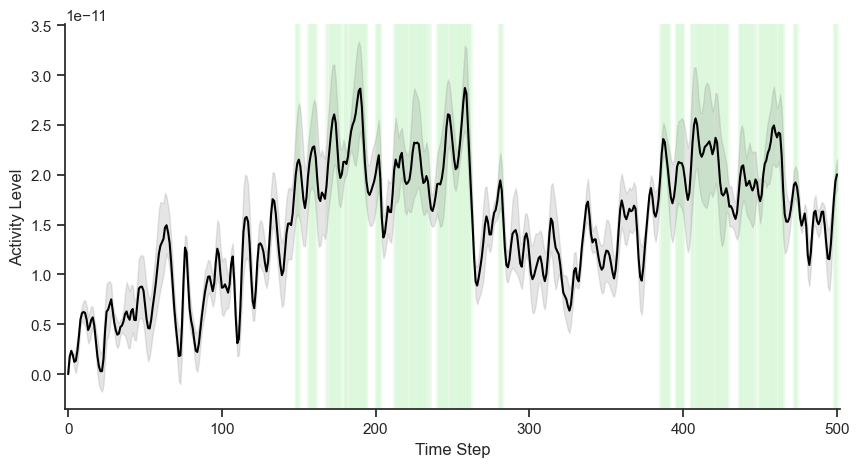

In [20]:
if p_value == 1.30103:
    COLOR = "lightgreen"
elif p_value == 2:
    COLOR = "lightblue"
elif p_value == 3:
    COLOR = "lightyellow"
 
 
# 计算每列的平均值和标准差  
label_data_mean_values = np.mean(label_data, axis=0)  
label_data_std_values = np.std(label_data, axis=0)  

sns.set(style='ticks')  
sns.despine()
# 计算阴影区域的上下边界  
upper_bound = label_data_mean_values + label_data_std_values  
lower_bound = label_data_mean_values - label_data_std_values  
plt.figure(figsize=(10,5))

# 绘制显著时间点的标记（淡绿色矩形）  
for index in effective_time_point:  
    # 设置矩形的位置和大小  
    # 假设矩形的高度足够高以覆盖整个y轴范围，宽度为1（因为是时间点）  
    # plt.axvspan(index - 0.5, index + 0.5, alpha=0.3, color='lightgreen', ymin=0, ymax=np.max(label_data))  
    plt.axvspan(index - 0.65, index + 0.65, alpha=0.1, color=COLOR, ymin=0, ymax=1)  


# 绘制平均值的线  
plt.plot(range(label_data.shape[1]), label_data_mean_values, label='Mean', color='black')  
  
# 绘制阴影区域  
plt.fill_between(range(label_data.shape[1]), lower_bound, upper_bound, alpha=0.2, color='gray')  
plt.xlim(xmin=-2,xmax=502)
# 设置x轴和y轴的标签  
plt.xlabel('Time Step')  
plt.ylabel('Activity Level')  
  
# 添加图例  
# plt.legend()  
sns.set(style='ticks')  
sns.despine()
# 显示图像  
plt.show()

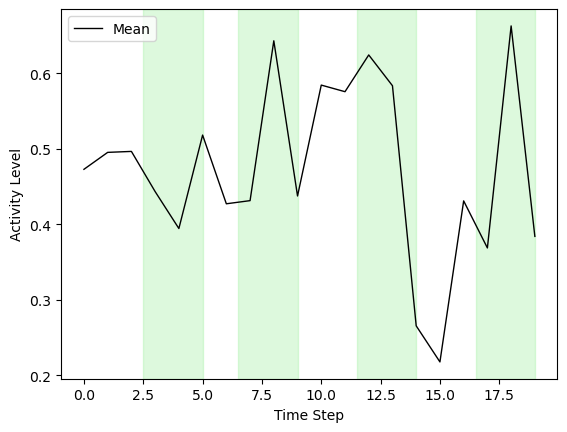

In [46]:
np.random.seed(0)  
data = np.random.rand(5, 20)  # 创建一个5x20的随机数据矩阵  
  
# 假设这些时间点（索引）与某个量显著相关  
significant_time_indices = [3, 7, 12, 17]  # 示例索引  
  
# 计算每列的平均值和标准差  
mean_values = np.mean(data, axis=0)  
  
# 绘制平均值的线  
plt.plot(range(data.shape[1]), mean_values, label='Mean', color='black', linewidth=1)  
  
# 绘制阴影区域（如果需要）  
# std_values = np.std(data, axis=0)  
# upper_bound = mean_values + std_values  
# lower_bound = mean_values - std_values  
# plt.fill_between(range(data.shape[1]), lower_bound, upper_bound, alpha=0.3, color='gray')  
  
# 绘制显著时间点的标记（淡绿色矩形）  
for index in significant_time_indices:  
    # 设置矩形的位置和大小  
    # 假设矩形的高度足够高以覆盖整个y轴范围，宽度为1（因为是时间点）  
    plt.axvspan(index - 0.5, index + 2.0, alpha=0.3, color='lightgreen', ymin=0, ymax=1)  
  
# 设置x轴和y轴的标签  
plt.xlabel('Time Step')  
plt.ylabel('Activity Level')  
  
# 添加图例  
plt.legend()  
  
# 显示网格（如果需要）  
# plt.grid(True)  
  
# 显示图像  
plt.show()

In [38]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
labels_beta = []
labels_time = []
labels_fraction = []
fraction = 0.50
p_value = 1.30103
# p_value = 2
# p_value = 3
for label in labels:
    label_effective_time = 0
    label_effective_beta = 0
    label_effective_fraction = 0
    
    label_data = stc_PEEX2.in_label(label).data
    label_data_p = stc_PEEX2_p.in_label(label).data

    for j in range(501):
        time_effective_point = 0
        time_effective_beta = 0
        for i in range(len(label_data[:,0])):
            if label_data_p[i,j]>p_value:
                # point_effective_beta += label_data[i,j]
                time_effective_point += 1
        if time_effective_point >= len(label_data[:,0])*fraction:
            for i in range(len(label_data[:,0])):
                time_effective_beta += label_data[i,j]
            label_effective_beta += np.abs(time_effective_beta)/len(label_data[:,0])
            label_effective_time += 1
            label_effective_fraction += time_effective_point/len(label_data[:,0])
            
    if label_effective_time != 0:
        labels_beta.append([label.name,label_effective_beta/label_effective_time])
        labels_fraction.append([label.name,label_effective_fraction/label_effective_time])
    else :
        labels_beta.append(0)
        labels_fraction.append(0)
    labels_time.append([label.name,label_effective_time])
if p_value == 1.30103:
    print("p < 0.05")
elif p_value == 2:
    print("p < 0.01")
elif p_value == 3:
    print("p < 0.001")
for i in range(len(labels_time)):
    if labels_time[i][1]>80:
        print(labels_time[i][0],'time',labels_time[i][1],'fraction','%.4f' % labels_fraction[i][1], 'beta','%.3E' % labels_beta[i][1])

Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
p < 0.05
bankssts_1-rh time 87 fraction 0.9253 beta 8.716E-12
inferiortemporal_6-rh time 85 fraction 0.9378 beta 1.196E-11
inferiortemporal_7-rh time 83 fraction 0.8988 beta 1.013E-11
lateraloccipital_3-rh time 87 fraction 0.7471 beta 8.259E-12
lateraloccipital_8-rh time 84 fraction 0.8777 beta 8.507E-12


In [7]:
labels = mne.read_labels_from_annot(subject, parc='aparc_sub', subjects_dir=subjects_dir)
labels_beta = []
labels_time = []
labels_fraction = []
fraction = 0.8
p_value = 1.30103
p_value = 2
p_value = 3
p_value = 5
for label in labels:
    label_effective_time = 0
    label_effective_beta = 0
    label_effective_fraction = 0
    
    label_data = stc_EFE2.in_label(label).data
    label_data_p = stc_EFE2_p.in_label(label).data

    for j in range(501):
        time_effective_point = 0
        time_effective_beta = 0
        for i in range(len(label_data[:,0])):
            if label_data_p[i,j]>p_value:
                # point_effective_beta += label_data[i,j]
                time_effective_point += 1
        if time_effective_point >= len(label_data[:,0])*fraction:
            for i in range(len(label_data[:,0])):
                time_effective_beta += label_data[i,j]
            label_effective_beta += time_effective_beta/len(label_data[:,0])
            label_effective_time += 1
            label_effective_fraction += time_effective_point/len(label_data[:,0])
            
    if label_effective_time != 0:
        labels_beta.append([label.name,label_effective_beta/label_effective_time])
        labels_fraction.append([label.name,label_effective_fraction/label_effective_time])
    else :
        labels_beta.append(0)
        labels_fraction.append(0)
    labels_time.append([label.name,label_effective_time])
if p_value == 1.30103:
    print("p < 0.05")
elif p_value == 2:
    print("p < 0.01")
elif p_value == 3:
    print("p < 0.001")
for i in range(len(labels_time)):
    if labels_time[i][1]>300:
        print(labels_time[i][0],'time',labels_time[i][1],'fraction','%.4f' % labels_fraction[i][1], 'beta','%.3E' % labels_beta[i][1])

Reading labels from parcellation...
   read 226 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc_sub.annot
   read 224 labels from C:\Users\dell\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc_sub.annot
middletemporal_5-lh time 314 fraction 0.9821 beta -3.541E-11
rostralmiddlefrontal_6-lh time 319 fraction 0.9821 beta -2.627E-11
